## Section 1: Structure & sanity checks

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path(r'C:\Personal\data')


In [72]:
df = pd.read_csv(DATA_DIR / 'incident_events.csv')
print('Shape:', df.shape)
df.head()

Shape: (69, 10)


,node,incidentDate,incidentDate2,description,category,beforeHours,afterHours,collectStart,collectEnd,windowTotalHours
0,node_38972d8a27de,11 Jul 2025,NaN,gpu problem,gpu error/problem,24,2,2025-07-10 00:00:00,2025-07-11 02:00:00,26
1,node_473ac80c8602,19 Jan 2025,NaN,gpu problem,gpu error/problem,24,2,2025-01-18 00:00:00,2025-01-19 02:00:00,26
2,node_2cad8ec37e1d,28 Jan 2025,NaN,gpu error,gpu error/problem,24,2,2025-01-27 00:00:00,2025-01-28 02:00:00,26
3,node_15e3440a80d0,07 Jan 2025,NaN,gpu ecc problem,gpu ecc,24,2,2025-01-06 00:00:00,2025-01-07 02:00:00,26
4,node_15e3440a80d0,14 Jan 2025,NaN,gpu ecc problem,gpu ecc,24,2,2025-01-13 00:00:00,2025-01-14 02:00:00,26


In [73]:
# how many unique categories total
print('Unique categories:', df['category'].nunique())

Unique categories: 8


In [74]:
# Data Types
print(df.dtypes)

node                    str
incidentDate            str
incidentDate2       float64
description             str
category                str
beforeHours           int64
afterHours            int64
collectStart            str
collectEnd              str
windowTotalHours      int64
dtype: object


In [75]:
df.isna().sum()

node                 0
incidentDate         0
incidentDate2       69
description          0
category             0
beforeHours          0
afterHours           0
collectStart         0
collectEnd           0
windowTotalHours     0
dtype: int64

In [76]:
df = df.drop(columns=["incidentDate2"])

In [77]:
df.head()

,node,incidentDate,description,category,beforeHours,afterHours,collectStart,collectEnd,windowTotalHours
0,node_38972d8a27de,11 Jul 2025,gpu problem,gpu error/problem,24,2,2025-07-10 00:00:00,2025-07-11 02:00:00,26
1,node_473ac80c8602,19 Jan 2025,gpu problem,gpu error/problem,24,2,2025-01-18 00:00:00,2025-01-19 02:00:00,26
2,node_2cad8ec37e1d,28 Jan 2025,gpu error,gpu error/problem,24,2,2025-01-27 00:00:00,2025-01-28 02:00:00,26
3,node_15e3440a80d0,07 Jan 2025,gpu ecc problem,gpu ecc,24,2,2025-01-06 00:00:00,2025-01-07 02:00:00,26
4,node_15e3440a80d0,14 Jan 2025,gpu ecc problem,gpu ecc,24,2,2025-01-13 00:00:00,2025-01-14 02:00:00,26


In [78]:
# convert date/time columns properly
df['incidentDate'] = pd.to_datetime(df['incidentDate'], format='%d %b %Y')
df['collectStart'] = pd.to_datetime(df['collectStart'])
df['collectEnd'] = pd.to_datetime(df['collectEnd'])

df[['node', 'incidentDate', 'collectStart', 'collectEnd']].head()

,node,incidentDate,collectStart,collectEnd
0,node_38972d8a27de,2025-07-11,2025-07-10,2025-07-11 02:00:00
1,node_473ac80c8602,2025-01-19,2025-01-18,2025-01-19 02:00:00
2,node_2cad8ec37e1d,2025-01-28,2025-01-27,2025-01-28 02:00:00
3,node_15e3440a80d0,2025-01-07,2025-01-06,2025-01-07 02:00:00
4,node_15e3440a80d0,2025-01-14,2025-01-13,2025-01-14 02:00:00


In [79]:
# confirm beforeHours / afterHours / windowTotalHours are constant
df[['beforeHours', 'afterHours', 'windowTotalHours']].drop_duplicates()

,beforeHours,afterHours,windowTotalHours
0,24,2,26


In [80]:
# confirm collectStart/collectEnd are just arithmetic derivations of incidentDate
check = df.copy()
check['expected_start'] = check['incidentDate'] - pd.to_timedelta(check['beforeHours'], unit='h')
check['expected_end'] = check['incidentDate'] + pd.to_timedelta(check['afterHours'], unit='h')

check['start_matches'] = check['expected_start'] == check['collectStart']
check['end_matches'] = check['expected_end'] == check['collectEnd']

print('All start times match formula:', check['start_matches'].all())
print('All end times match formula:', check['end_matches'].all())

All start times match formula: True
All end times match formula: True


## Section 2: Nodel-level Distribution

In [81]:
print('Unique nodes:', df['node'].nunique())
print('Total incidents:', len(df))

Unique nodes: 26
Total incidents: 69


In [82]:
incidents_per_node = df['node'].value_counts()
incidents_per_node

node
node_ada68b80182e    15
node_95799a17101c    11
node_6a5ebc855306     5
node_2348d3608e24     5
node_b1b91a387252     3
node_039ab2df8a6a     3
node_dfc60a085f94     3
node_1a061e79b6d1     3
node_15e3440a80d0     2
node_82d89aec502a     2
node_484a8d060485     2
node_38972d8a27de     1
node_473ac80c8602     1
node_2cad8ec37e1d     1
node_0876e5fac0c8     1
node_2b08d249c0ba     1
node_df3724dfcace     1
node_62a6cb9d8856     1
node_d4119f476626     1
node_eb787fe5e4fa     1
node_d66992a09544     1
node_c1c418ff5f95     1
node_a4bc1d905d62     1
node_b33671ad48fb     1
node_39a26f4a5528     1
node_d603d0ec5d69     1
Name: count, dtype: int64

In [83]:
# how many nodes have only 1 incident vs multiple
single_incident_nodes = (incidents_per_node == 1).sum()
multi_incident_nodes = (incidents_per_node > 1).sum()

print('Nodes with exactly 1 incident:', single_incident_nodes)
print('Nodes with multiple incidents:', multi_incident_nodes)

Nodes with exactly 1 incident: 15
Nodes with multiple incidents: 11


In [84]:
# the repeat offenders
incidents_per_node[incidents_per_node > 1]

node
node_ada68b80182e    15
node_95799a17101c    11
node_6a5ebc855306     5
node_2348d3608e24     5
node_b1b91a387252     3
node_039ab2df8a6a     3
node_dfc60a085f94     3
node_1a061e79b6d1     3
node_15e3440a80d0     2
node_82d89aec502a     2
node_484a8d060485     2
Name: count, dtype: int64

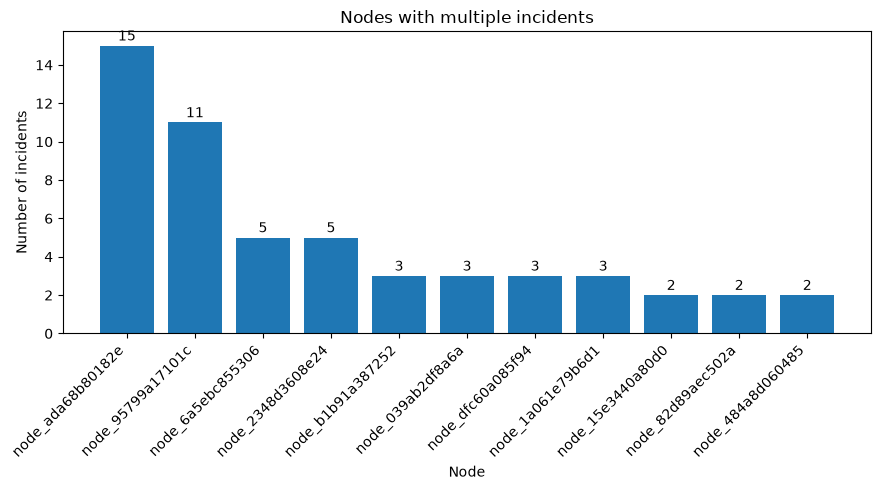

In [85]:
repeat_nodes = incidents_per_node[incidents_per_node > 1]

plt.figure(figsize=(9, 5))
bars = plt.bar(repeat_nodes.index, repeat_nodes.values)

# add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, int(height),
              ha='center', va='bottom')

plt.xlabel('Node')
plt.ylabel('Number of incidents')
plt.title('Nodes with multiple incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Section 3: Category / description analysis

In [86]:
# full category value counts - is this a clean small set usable as a label?
print('Incidents per category:', df['category'].value_counts())
# how many unique categories total
print('\nUnique categories:', df['category'].nunique())

Incidents per category: category
gpu error/problem    31
gpu fell off bus     24
gpu unknown           5
gpu lost              3
gpu ecc               2
gpu failed            2
gpu timeout           1
gpu handle error      1
Name: count, dtype: int64

Unique categories: 8


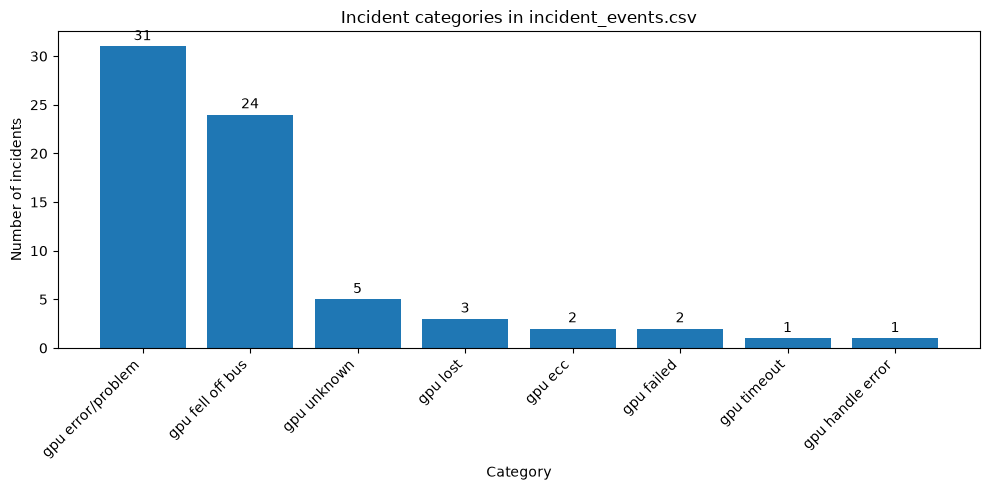

In [87]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(category_counts.index, category_counts.values)

# add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, int(height),
              ha='center', va='bottom')

plt.xlabel('Category')
plt.ylabel('Number of incidents')
plt.title('Incident categories in incident_events.csv')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [88]:
# description -> category mapping: how much free-text variation collapses into each category
for cat, descs in df.groupby('category')['description'].unique().items():
    print(f'{cat}:')
    for d in descs:
        print(f'   - {d}')
    print()

gpu ecc:
   - gpu ecc problem

gpu error/problem:
   - gpu problem
   - gpu error
   - gpus uncooperative
   - gpus error

gpu failed:
   - gpus failed

gpu fell off bus:
   - gpu fell off bus
   - gpus fell off bus
   - gpus fell of bus

gpu handle error:
   - unable to determine gpu handle

gpu lost:
   - lost gpu

gpu timeout:
   - gpu timeout

gpu unknown:
   - gpus unknown error



In [89]:
# flag categories that look ambiguous/low-confidence as labels
ambiguous_keywords = ['unknown', 'uncooperative', 'unable to determine']
df['looks_ambiguous'] = df['description'].str.lower().str.contains('|'.join(ambiguous_keywords))

print('Ambiguous-sounding incidents:', df['looks_ambiguous'].sum())
df[df['looks_ambiguous']][['node', 'incidentDate', 'description', 'category']]

Ambiguous-sounding incidents: 7


,node,incidentDate,description,category
26,node_95799a17101c,2025-10-02,gpus unknown error,gpu unknown
28,node_95799a17101c,2025-10-11,gpus uncooperative,gpu error/problem
30,node_95799a17101c,2026-02-10,gpus unknown error,gpu unknown
31,node_95799a17101c,2026-02-12,gpus unknown error,gpu unknown
39,node_ada68b80182e,2025-04-27,gpus unknown error,gpu unknown
46,node_ada68b80182e,2026-02-11,gpus unknown error,gpu unknown
62,node_1a061e79b6d1,2025-09-12,unable to determine gpu handle,gpu handle error


## Section 4: Temporal analysis

In [90]:
print('Earliest incident:', df['incidentDate'].min())
print('Latest incident:', df['incidentDate'].max())
print('Total span (days):', (df['incidentDate'].max() - df['incidentDate'].min()).days)

Earliest incident: 2025-01-07 00:00:00
Latest incident: 2026-02-12 00:00:00
Total span (days): 401


In [91]:
unique_incident_days = df['incidentDate'].nunique()
print('Unique incident days:', unique_incident_days)

Unique incident days: 44


In [92]:
# incident counts per exact date - looking for same-day clusters across multiple nodes
date_counts = df['incidentDate'].value_counts().sort_index()
date_counts

incidentDate
2025-01-07    1
2025-01-11    1
2025-01-12    1
2025-01-14    2
2025-01-15    1
2025-01-16    1
2025-01-19    1
2025-01-27    2
2025-01-28    1
2025-02-07    1
2025-02-10    3
2025-02-17    2
2025-03-14    2
2025-03-19    2
2025-03-21    6
2025-04-26    3
2025-04-27    1
2025-05-07    1
2025-05-20    2
2025-06-11    1
2025-06-12    2
2025-06-14    1
2025-06-24    1
2025-07-03    2
2025-07-04    1
2025-07-06    1
2025-07-11    1
2025-07-13    1
2025-09-12    4
2025-09-29    2
2025-10-02    1
2025-10-10    3
2025-10-11    1
2025-10-21    1
2025-10-22    1
2026-01-09    1
2026-01-10    1
2026-01-13    1
2026-01-19    3
2026-01-22    1
2026-02-06    1
2026-02-10    1
2026-02-11    1
2026-02-12    1
Name: count, dtype: int64

In [93]:
# isolate dates where MULTIPLE DIFFERENT nodes had incidents on the same day
multi_node_dates = df.groupby('incidentDate')['node'].nunique()
multi_node_dates = multi_node_dates[multi_node_dates > 1]
print(multi_node_dates)

print('Total dates with multi-node clusters:', len(multi_node_dates))
print('Total incidents involved in these clusters:', multi_node_dates.sum())

incidentDate
2025-01-14    2
2025-01-27    2
2025-02-10    3
2025-02-17    2
2025-03-14    2
2025-03-19    2
2025-03-21    6
2025-04-26    3
2025-05-20    2
2025-06-12    2
2025-07-03    2
2025-09-12    4
2025-09-29    2
2025-10-10    3
2026-01-19    3
Name: node, dtype: int64
Total dates with multi-node clusters: 15
Total incidents involved in these clusters: 40


In [94]:
# for each clustered date, show exactly which nodes and categories were involved
for date in multi_node_dates.index:
    print(f'--- {date.date()} ---')
    print(df[df['incidentDate'] == date][['node', 'category', 'description']].to_string(index=False))
    print()

--- 2025-01-14 ---
             node          category     description
node_15e3440a80d0           gpu ecc gpu ecc problem
node_95799a17101c gpu error/problem     gpu problem

--- 2025-01-27 ---
             node          category description
node_c1c418ff5f95 gpu error/problem   gpu error
node_39a26f4a5528 gpu error/problem   gpu error

--- 2025-02-10 ---
             node          category description
node_2b08d249c0ba gpu error/problem   gpu error
node_d66992a09544 gpu error/problem   gpu error
node_b33671ad48fb gpu error/problem   gpu error

--- 2025-02-17 ---
             node         category       description
node_6a5ebc855306 gpu fell off bus gpus fell off bus
node_ada68b80182e gpu fell off bus gpus fell off bus

--- 2025-03-14 ---
             node          category       description
node_ada68b80182e  gpu fell off bus gpus fell off bus
node_2348d3608e24 gpu error/problem         gpu error

--- 2025-03-19 ---
             node          category       description
node_6a5ebc855

In [95]:
# isolate all rows that fall on a multi-node clustered date
cluster_rows = df[df['incidentDate'].isin(multi_node_dates.index)]

print('Total incidents involved in clustered dates:', len(cluster_rows))
print()

# which category appeared most within these clusters?
print('Category breakdown within clustered dates:')
print(cluster_rows['category'].value_counts())

Total incidents involved in clustered dates: 40

Category breakdown within clustered dates:
category
gpu error/problem    20
gpu fell off bus     17
gpu ecc               1
gpu lost              1
gpu handle error      1
Name: count, dtype: int64


In [96]:
# node breakdown for the 40 incidents that fall on clustered dates
cluster_rows['node'].value_counts()

node
node_ada68b80182e    6
node_6a5ebc855306    5
node_95799a17101c    4
node_039ab2df8a6a    3
node_dfc60a085f94    3
node_1a061e79b6d1    3
node_2348d3608e24    3
node_15e3440a80d0    1
node_2b08d249c0ba    1
node_b1b91a387252    1
node_df3724dfcace    1
node_62a6cb9d8856    1
node_d4119f476626    1
node_d66992a09544    1
node_c1c418ff5f95    1
node_a4bc1d905d62    1
node_b33671ad48fb    1
node_39a26f4a5528    1
node_d603d0ec5d69    1
node_484a8d060485    1
Name: count, dtype: int64

In [97]:
# nodes that appear on clustered dates AND are also repeat-incident nodes overall
cluster_nodes = set(cluster_rows['node'].unique())
repeat_nodes_overall = set(incidents_per_node[incidents_per_node > 1].index)

nodes_both = cluster_nodes & repeat_nodes_overall
print('Nodes that are BOTH repeat-incident overall AND appeared on a clustered date:')
print(nodes_both)

Nodes that are BOTH repeat-incident overall AND appeared on a clustered date:
{'node_dfc60a085f94', 'node_b1b91a387252', 'node_039ab2df8a6a', 'node_1a061e79b6d1', 'node_484a8d060485', 'node_2348d3608e24', 'node_6a5ebc855306', 'node_ada68b80182e', 'node_95799a17101c', 'node_15e3440a80d0'}


In [98]:
# for those nodes, show their full incident history (not just the clustered-date row)
if nodes_both:
    full_history = df[df['node'].isin(nodes_both)][['node', 'incidentDate', 'category', 'description']].sort_values(['node', 'incidentDate'])
    full_history
else:
    print('No overlap - the clustered-date nodes are all otherwise single-incident nodes.')

In [99]:
# flag within that history which specific row was the clustered-date incident
if nodes_both:
    full_history = full_history.copy()
    full_history['is_clustered_incident'] = full_history['incidentDate'].isin(multi_node_dates.index)
    full_history

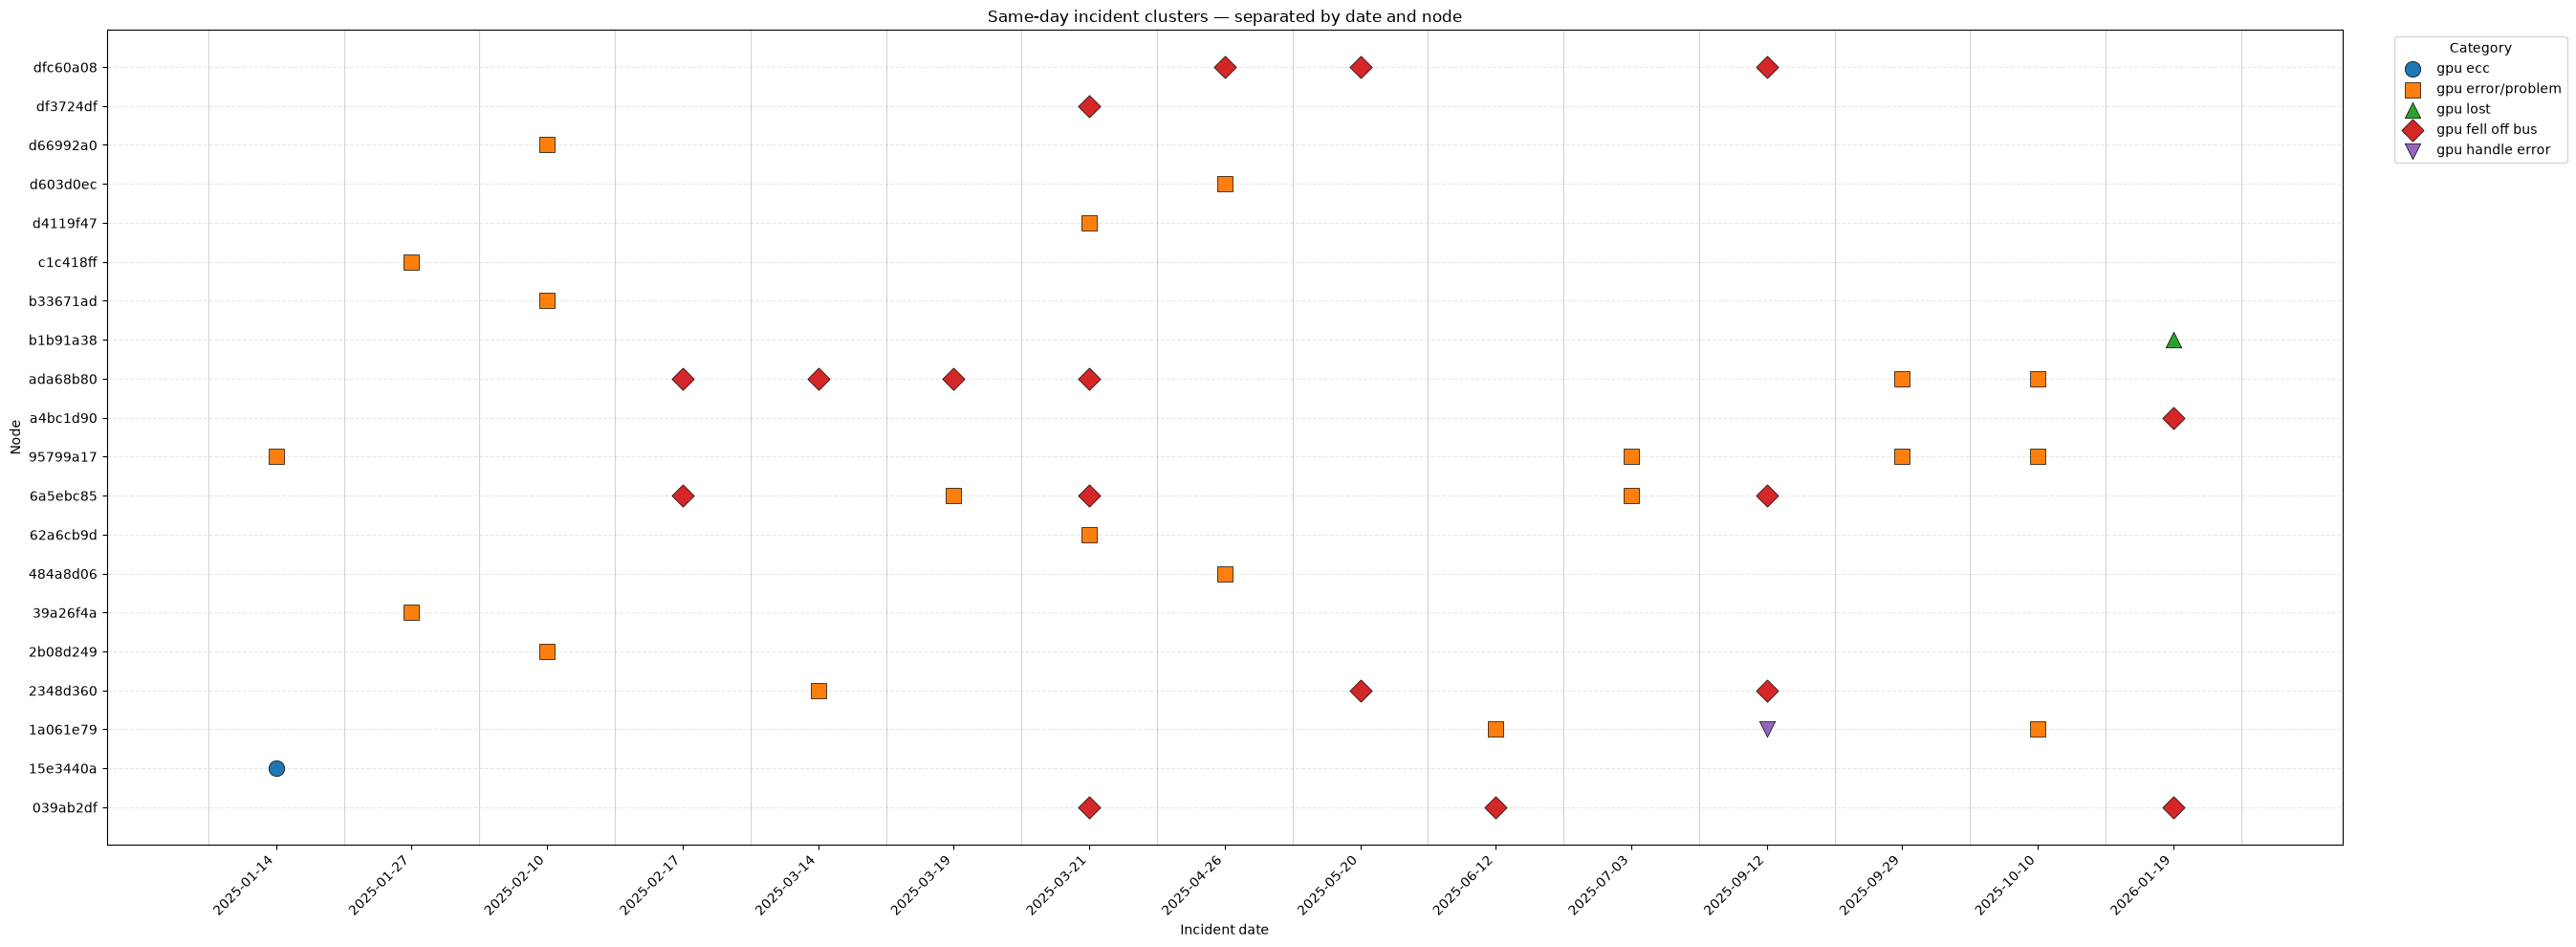

In [100]:
import matplotlib.pyplot as plt

cluster_df = df[df['incidentDate'].isin(multi_node_dates.index)].copy()
cluster_df['date_str'] = cluster_df['incidentDate'].dt.strftime('%Y-%m-%d')
cluster_df['node_short'] = cluster_df['node'].str.replace('node_', '').str[:8]

dates_sorted = sorted(cluster_df['date_str'].unique())
nodes_sorted = sorted(cluster_df['node_short'].unique())

categories = cluster_df['category'].unique()
colors = plt.cm.tab10.colors
markers = ['o', 's', '^', 'D', 'v', 'P', 'X']
category_style = {
    cat: (colors[i % len(colors)], markers[i % len(markers)])
    for i, cat in enumerate(categories)
}

fig, ax = plt.subplots(figsize=(max(8, len(dates_sorted) * 1.8), max(4, len(nodes_sorted) * 0.5)))

# vertical separators between each date group for clear visual separation
for i in range(len(dates_sorted) + 1):
    ax.axvline(i - 0.5, color='lightgray', linewidth=0.8, zorder=0)

for cat in categories:
    color, marker = category_style[cat]
    sub = cluster_df[cluster_df['category'] == cat]
    x = [dates_sorted.index(d) for d in sub['date_str']]
    y = [nodes_sorted.index(n) for n in sub['node_short']]
    ax.scatter(x, y, label=cat, color=color, marker=marker, s=140, edgecolor='black', linewidth=0.5, zorder=3)

ax.set_xticks(range(len(dates_sorted)))
ax.set_xticklabels(dates_sorted, rotation=45, ha='right')
ax.set_yticks(range(len(nodes_sorted)))
ax.set_yticklabels(nodes_sorted)

ax.set_xlabel('Incident date')
ax.set_ylabel('Node')
ax.set_title('Same-day incident clusters — separated by date and node')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

In [101]:
# incidents per month - check for seasonality/trend over the ~13 month window
df['incidentMonth'] = df['incidentDate'].dt.to_period('M')
df['incidentMonth'].value_counts().sort_index()

incidentMonth
2025-01    11
2025-02     6
2025-03    10
2025-04     4
2025-05     3
2025-06     5
2025-07     6
2025-09     6
2025-10     7
2026-01     7
2026-02     4
Freq: M, Name: count, dtype: int64

## Section 5: Cross Reference with Manifest.csv

In [102]:
manifest = pd.read_csv(r'C:\Personal\data\manifest.csv')

# only incident-type files matter here, not healthy reference windows
manifest_incidents = manifest[manifest['inputType'] == 'label-heavy-prometheus']
manifest_incidents[['inputFile', 'node', 'minTime', 'maxTime']]

,inputFile,node,minTime,maxTime
0,ggpu121_2025-02-10_gpu-error.csv.bz2,node_2b08d249c0ba,2025-02-03 00:00:00,2025-02-12 23:50:00
1,ggpu129_2026-01-09_gpu-lost.csv.bz2,node_b1b91a387252,2026-01-02 00:00:00,2026-01-11 23:50:00
2,ggpu129_2026-01-13_gpu-lost.csv.bz2,node_b1b91a387252,2026-01-06 00:00:00,2026-01-15 23:50:00
3,ggpu129_2026-01-19_gpu-lost.csv.bz2,node_b1b91a387252,2026-01-12 00:00:00,2026-01-21 23:50:00
4,ggpu139_2025-03-21_gpus-dropped-off-bus-maybe....,node_df3724dfcace,2025-03-14 00:00:00,2025-03-23 23:50:00
5,ggpu142_2025-02-17_gpus-fallen-off-bus.csv.bz2,node_6a5ebc855306,2025-02-10 00:00:00,2025-02-19 23:50:00
6,ggpu142_2025-03-15_unknown-error-possibly-nong...,node_6a5ebc855306,2025-03-08 00:00:00,2025-03-17 23:50:00
7,ggpu142_2025-03-19_gpu-problem.csv.bz2,node_6a5ebc855306,2025-03-12 00:00:00,2025-03-21 23:50:00
8,ggpu142_2025-03-21_gpus-fell-off-bus.csv.bz2,node_6a5ebc855306,2025-03-14 00:00:00,2025-03-23 23:50:00
9,ggpu142_2025-07-03_gpu-problem.csv.bz2,node_6a5ebc855306,2025-06-26 00:00:00,2025-07-05 23:50:00


In [103]:
# which of the 26 nodes have telemetry pulled?
manifest_nodes = set(manifest_incidents['node'].dropna().unique())
all_incident_nodes = set(df['node'].unique())

print('Nodes in incident_events.csv:', len(all_incident_nodes))
print('Nodes with telemetry pulled:', len(manifest_nodes))
print()
print('Nodes WITHOUT telemetry:', len(all_incident_nodes - manifest_nodes))

Nodes in incident_events.csv: 26
Nodes with telemetry pulled: 7

Nodes WITHOUT telemetry: 19


In [104]:
# add a has_telemetry flag to the incident-level dataframe
df['has_telemetry'] = df['node'].isin(manifest_nodes)

df['has_telemetry'].value_counts()

has_telemetry
False    54
True     15
Name: count, dtype: int64

In [105]:
# coverage table: every incident row, flagged whether telemetry exists
coverage_table = df[['node', 'incidentDate', 'category', 'description', 'has_telemetry']].sort_values(['node', 'incidentDate'])
coverage_table

,node,incidentDate,category,description,has_telemetry
18,node_039ab2df8a6a,2025-03-21,gpu fell off bus,gpus fell off bus,True
19,node_039ab2df8a6a,2025-06-12,gpu fell off bus,gpus fell off bus,True
20,node_039ab2df8a6a,2026-01-19,gpu fell off bus,gpus fell off bus,True
5,node_0876e5fac0c8,2025-10-22,gpu fell off bus,gpu fell off bus,False
3,node_15e3440a80d0,2025-01-07,gpu ecc,gpu ecc problem,False
...,...,...,...,...,...
10,node_df3724dfcace,2025-03-21,gpu fell off bus,gpus fell off bus,True
56,node_dfc60a085f94,2025-04-26,gpu fell off bus,gpus fell off bus,False
57,node_dfc60a085f94,2025-05-20,gpu fell off bus,gpu fell off bus,False
58,node_dfc60a085f94,2025-09-12,gpu fell off bus,gpu fell off bus,False


In [106]:
# for the 7 covered nodes specifically: do ALL their incidents have telemetry, or only some?
covered_node_incidents = df[df['node'].isin(manifest_nodes)]

incidents_per_covered_node = covered_node_incidents.groupby('node').size()
telemetry_files_per_node = manifest_incidents.groupby('node').size()

comparison = pd.DataFrame({
    'incidents_in_log': incidents_per_covered_node,
    'telemetry_files_pulled': telemetry_files_per_node
}).fillna(0).astype(int)

comparison['fully_covered'] = comparison['incidents_in_log'] == comparison['telemetry_files_pulled']
comparison

,incidents_in_log,telemetry_files_pulled,fully_covered
node,,,
node_039ab2df8a6a,3,3,True
node_2b08d249c0ba,1,1,True
node_62a6cb9d8856,1,1,True
node_6a5ebc855306,5,6,False
node_b1b91a387252,3,3,True
node_d4119f476626,1,1,True
node_df3724dfcace,1,1,True


In [107]:
target_node = 'node_6a5ebc855306'

print('=== incident_events.csv rows for this node ===')
print(df[df['node'] == target_node][['incidentDate', 'category', 'description']].to_string(index=False))
print()

print('=== manifest.csv telemetry files for this node ===')
print(manifest_incidents[manifest_incidents['node'] == target_node][['inputFile', 'minTime', 'maxTime']].to_string(index=False))

=== incident_events.csv rows for this node ===
incidentDate          category       description
  2025-02-17  gpu fell off bus gpus fell off bus
  2025-03-19 gpu error/problem       gpu problem
  2025-03-21  gpu fell off bus gpus fell off bus
  2025-07-03 gpu error/problem       gpu problem
  2025-09-12  gpu fell off bus gpus fell off bus

=== manifest.csv telemetry files for this node ===
                                               inputFile             minTime             maxTime
          ggpu142_2025-02-17_gpus-fallen-off-bus.csv.bz2 2025-02-10 00:00:00 2025-02-19 23:50:00
ggpu142_2025-03-15_unknown-error-possibly-nongpu.csv.bz2 2025-03-08 00:00:00 2025-03-17 23:50:00
                  ggpu142_2025-03-19_gpu-problem.csv.bz2 2025-03-12 00:00:00 2025-03-21 23:50:00
            ggpu142_2025-03-21_gpus-fell-off-bus.csv.bz2 2025-03-14 00:00:00 2025-03-23 23:50:00
                  ggpu142_2025-07-03_gpu-problem.csv.bz2 2025-06-26 00:00:00 2025-07-05 23:50:00
         ggpu142_2025-09-

In [108]:
# Build a side-by-side comparison: logged incident dates vs telemetry filenames, per node

target_node = 'node_6a5ebc855306'

logged_dates = df[df['node'] == target_node][['incidentDate']].copy()
logged_dates['incidentDate'] = logged_dates['incidentDate'].dt.date

telemetry_files = manifest_incidents[manifest_incidents['node'] == target_node][['inputFile']].copy()

# extract the date embedded in the filename, e.g. "ggpu142_2025-03-15_..." -> 2025-03-15
telemetry_files['fileDate'] = pd.to_datetime(
    telemetry_files['inputFile'].str.extract(r'_(\d{4}-\d{2}-\d{2})_')[0]
).dt.date

# outer join on date so unmatched rows on either side still show up
comparison = pd.merge(
    logged_dates, telemetry_files,
    left_on='incidentDate', right_on='fileDate',
    how='outer'
).sort_values(by=['incidentDate', 'fileDate'], na_position='last')

comparison['matched'] = comparison['incidentDate'].notna() & comparison['fileDate'].notna()

comparison[['incidentDate', 'inputFile', 'matched']]

,incidentDate,inputFile,matched
0,2025-02-17,ggpu142_2025-02-17_gpus-fallen-off-bus.csv.bz2,True
2,2025-03-19,ggpu142_2025-03-19_gpu-problem.csv.bz2,True
3,2025-03-21,ggpu142_2025-03-21_gpus-fell-off-bus.csv.bz2,True
4,2025-07-03,ggpu142_2025-07-03_gpu-problem.csv.bz2,True
5,2025-09-12,ggpu142_2025-09-12_gpus-dropped-off-bus.csv.bz2,True
1,NaN,ggpu142_2025-03-15_unknown-error-possibly-nong...,False


In [109]:
# incidents per node, across ALL 26 nodes (not just the 7 covered ones)
incidents_per_node_all = df['node'].value_counts()

# build a comparison table: incident count vs whether telemetry exists
node_comparison = pd.DataFrame({
    'incidents_in_log': incidents_per_node_all
})
node_comparison['has_telemetry'] = node_comparison.index.isin(manifest_nodes)

node_comparison = node_comparison.sort_values('incidents_in_log', ascending=False)
node_comparison

,incidents_in_log,has_telemetry
node,,
node_ada68b80182e,15,False
node_95799a17101c,11,False
node_6a5ebc855306,5,True
node_2348d3608e24,5,False
node_b1b91a387252,3,True
node_039ab2df8a6a,3,True
node_dfc60a085f94,3,False
node_1a061e79b6d1,3,False
node_15e3440a80d0,2,False


In [110]:
# focus specifically on repeat-incident nodes (>1) and see how many were actually selected for telemetry
repeat_nodes_all = node_comparison[node_comparison['incidents_in_log'] > 1]
repeat_nodes_all

,incidents_in_log,has_telemetry
node,,
node_ada68b80182e,15,False
node_95799a17101c,11,False
node_6a5ebc855306,5,True
node_2348d3608e24,5,False
node_b1b91a387252,3,True
node_039ab2df8a6a,3,True
node_dfc60a085f94,3,False
node_1a061e79b6d1,3,False
node_15e3440a80d0,2,False


In [111]:
# for repeat-incident nodes, show which categories they had
repeat_node_categories = df[df['node'].isin(repeat_nodes_all.index)].groupby(['node', 'category']).size().unstack(fill_value=0)

# join back with the has_telemetry info for full context
repeat_node_categories['has_telemetry'] = repeat_node_categories.index.isin(manifest_nodes)

repeat_node_categories

category,gpu ecc,gpu error/problem,gpu failed,gpu fell off bus,gpu handle error,gpu lost,gpu timeout,gpu unknown,has_telemetry
node,,,,,,,,,
node_039ab2df8a6a,0,0,0,3,0,0,0,0,True
node_15e3440a80d0,2,0,0,0,0,0,0,0,False
node_1a061e79b6d1,0,2,0,0,1,0,0,0,False
node_2348d3608e24,0,1,0,4,0,0,0,0,False
node_484a8d060485,0,1,0,0,0,0,1,0,False
node_6a5ebc855306,0,2,0,3,0,0,0,0,True
node_82d89aec502a,0,2,0,0,0,0,0,0,False
node_95799a17101c,0,7,0,1,0,0,0,3,False
node_ada68b80182e,0,4,2,7,0,0,0,2,False


In [112]:
for node in repeat_nodes_all.index:
    cats = df[df['node'] == node]['category'].value_counts()
    telemetry_flag = 'HAS telemetry' if node in manifest_nodes else 'no telemetry'
    print(f'--- {node} ({telemetry_flag}) ---')
    print(cats)
    print()

--- node_ada68b80182e (no telemetry) ---
category
gpu fell off bus     7
gpu error/problem    4
gpu unknown          2
gpu failed           2
Name: count, dtype: int64

--- node_95799a17101c (no telemetry) ---
category
gpu error/problem    7
gpu unknown          3
gpu fell off bus     1
Name: count, dtype: int64

--- node_6a5ebc855306 (HAS telemetry) ---
category
gpu fell off bus     3
gpu error/problem    2
Name: count, dtype: int64

--- node_2348d3608e24 (no telemetry) ---
category
gpu fell off bus     4
gpu error/problem    1
Name: count, dtype: int64

--- node_b1b91a387252 (HAS telemetry) ---
category
gpu lost    3
Name: count, dtype: int64

--- node_039ab2df8a6a (HAS telemetry) ---
category
gpu fell off bus    3
Name: count, dtype: int64

--- node_dfc60a085f94 (no telemetry) ---
category
gpu fell off bus    3
Name: count, dtype: int64

--- node_1a061e79b6d1 (no telemetry) ---
category
gpu error/problem    2
gpu handle error     1
Name: count, dtype: int64

--- node_15e3440a80d0 (n

In [113]:
# summary: of all nodes with multiple incidents, how many got telemetry vs not?
print('Total nodes with >1 incident:', len(repeat_nodes_all))
print('Of those, telemetry pulled:', repeat_nodes_all['has_telemetry'].sum())
print('Of those, NO telemetry pulled:', (~repeat_nodes_all['has_telemetry']).sum())

Total nodes with >1 incident: 11
Of those, telemetry pulled: 3
Of those, NO telemetry pulled: 8


In [114]:
# and the reverse check: are there single-incident nodes that DID get telemetry?
single_incident_nodes_all = node_comparison[node_comparison['incidents_in_log'] == 1]
print('Single-incident nodes with telemetry:', single_incident_nodes_all['has_telemetry'].sum())
print('Single-incident nodes without telemetry:', (~single_incident_nodes_all['has_telemetry']).sum())

Single-incident nodes with telemetry: 4
Single-incident nodes without telemetry: 11


In [115]:
# filter incident_events.csv down to only the nodes that have telemetry pulled
covered_incidents = df[df['node'].isin(manifest_nodes)]

covered_incidents[['node', 'incidentDate', 'category', 'description']].sort_values(['node', 'incidentDate'])

,node,incidentDate,category,description
18,node_039ab2df8a6a,2025-03-21,gpu fell off bus,gpus fell off bus
19,node_039ab2df8a6a,2025-06-12,gpu fell off bus,gpus fell off bus
20,node_039ab2df8a6a,2026-01-19,gpu fell off bus,gpus fell off bus
6,node_2b08d249c0ba,2025-02-10,gpu error/problem,gpu error
16,node_62a6cb9d8856,2025-03-21,gpu error/problem,gpu problem
11,node_6a5ebc855306,2025-02-17,gpu fell off bus,gpus fell off bus
12,node_6a5ebc855306,2025-03-19,gpu error/problem,gpu problem
13,node_6a5ebc855306,2025-03-21,gpu fell off bus,gpus fell off bus
14,node_6a5ebc855306,2025-07-03,gpu error/problem,gpu problem
15,node_6a5ebc855306,2025-09-12,gpu fell off bus,gpus fell off bus


In [116]:
# category breakdown, but only for telemetry-covered nodes
covered_incidents['category'].value_counts()

category
gpu fell off bus     7
gpu error/problem    5
gpu lost             3
Name: count, dtype: int64

In [117]:
# compare that against the FULL dataset's category breakdown (all 26 nodes)
comparison_categories = pd.DataFrame({
    'all_nodes': df['category'].value_counts(),
    'telemetry_covered_nodes': covered_incidents['category'].value_counts()
}).fillna(0).astype(int)

comparison_categories

,all_nodes,telemetry_covered_nodes
category,,
gpu ecc,2,0
gpu error/problem,31,5
gpu failed,2,0
gpu fell off bus,24,7
gpu handle error,1,0
gpu lost,3,3
gpu timeout,1,0
gpu unknown,5,0


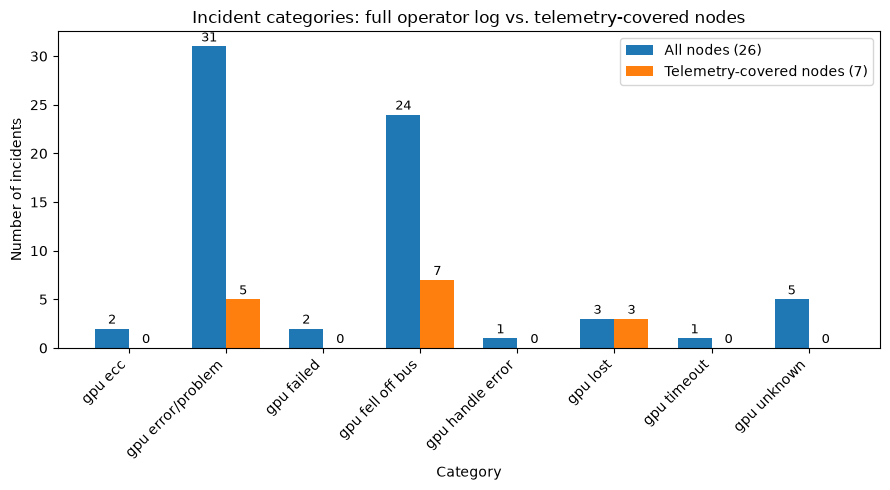

In [118]:
import matplotlib.pyplot as plt
import numpy as np

comparison_categories = pd.DataFrame({
    'all_nodes': df['category'].value_counts(),
    'telemetry_covered_nodes': covered_incidents['category'].value_counts()
}).fillna(0).astype(int)

categories = comparison_categories.index
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, comparison_categories['all_nodes'], width, label='All nodes (26)')
bars2 = ax.bar(x + width/2, comparison_categories['telemetry_covered_nodes'], width, label='Telemetry-covered nodes (7)')

# data labels on both sets of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.2, int(height),
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Category')
ax.set_ylabel('Number of incidents')
ax.set_title('Incident categories: full operator log vs. telemetry-covered nodes')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [119]:
# category breakdown PER covered node - does each node show one category or a mix?
category_by_node = covered_incidents.groupby(['node', 'category']).size().unstack(fill_value=0)
category_by_node

category,gpu error/problem,gpu fell off bus,gpu lost
node,,,
node_039ab2df8a6a,0,3,0
node_2b08d249c0ba,1,0,0
node_62a6cb9d8856,1,0,0
node_6a5ebc855306,2,3,0
node_b1b91a387252,0,0,3
node_d4119f476626,1,0,0
node_df3724dfcace,0,1,0


In [120]:
incidents_per_node_all.sort_values(ascending=False).head(5)

node
node_ada68b80182e    15
node_95799a17101c    11
node_6a5ebc855306     5
node_2348d3608e24     5
node_b1b91a387252     3
Name: count, dtype: int64

In [125]:
# category breakdown per node, across ALL 26 nodes in incident_events.csv
all_node_category_table = df.groupby(['node', 'category']).size().unstack(fill_value=0)

all_node_category_table['total_incidents'] = all_node_category_table.sum(axis=1)
cols = ['total_incidents'] + [c for c in all_node_category_table.columns if c != 'total_incidents']
all_node_category_table = all_node_category_table[cols]

# add whether telemetry exists for each node, for context
all_node_category_table['has_telemetry'] = all_node_category_table.index.isin(manifest_nodes)

all_node_category_table = all_node_category_table.sort_values('total_incidents', ascending=False)
all_node_category_table

category,total_incidents,gpu ecc,gpu error/problem,gpu failed,gpu fell off bus,gpu handle error,gpu lost,gpu timeout,gpu unknown,has_telemetry
node,,,,,,,,,,
node_ada68b80182e,15,0,4,2,7,0,0,0,2,False
node_95799a17101c,11,0,7,0,1,0,0,0,3,False
node_2348d3608e24,5,0,1,0,4,0,0,0,0,False
node_6a5ebc855306,5,0,2,0,3,0,0,0,0,True
node_1a061e79b6d1,3,0,2,0,0,1,0,0,0,False
node_dfc60a085f94,3,0,0,0,3,0,0,0,0,False
node_b1b91a387252,3,0,0,0,0,0,3,0,0,True
node_039ab2df8a6a,3,0,0,0,3,0,0,0,0,True
node_484a8d060485,2,0,1,0,0,0,0,1,0,False


In [130]:
# ALL 26 nodes: for repeat-incident nodes, find how many of their incidents share the same (most common) category
repeat_nodes_all_ids = incidents_per_node[incidents_per_node > 1].index

same_category_all = []
for node in repeat_nodes_all_ids:
    cats = df[df['node'] == node]['category']
    top_category = cats.value_counts().idxmax()
    top_count = cats.value_counts().max()
    total = len(cats)
    same_category_all.append({
        'node': node,
        'total_incidents': total,
        'most_common_category': top_category,
        'same_category_count': top_count,
        'all_same_category': top_count == total
    })

same_category_all_df = pd.DataFrame(same_category_all).sort_values('total_incidents', ascending=False)
same_category_all_df['same_category_pct'] = (
    same_category_all_df['same_category_count'] / same_category_all_df['total_incidents'] * 100
).round(1)

same_category_all_df

,node,total_incidents,most_common_category,same_category_count,all_same_category,same_category_pct
0,node_ada68b80182e,15,gpu fell off bus,7,False,46.7
1,node_95799a17101c,11,gpu error/problem,7,False,63.6
2,node_6a5ebc855306,5,gpu fell off bus,3,False,60.0
3,node_2348d3608e24,5,gpu fell off bus,4,False,80.0
4,node_b1b91a387252,3,gpu lost,3,True,100.0
5,node_039ab2df8a6a,3,gpu fell off bus,3,True,100.0
6,node_dfc60a085f94,3,gpu fell off bus,3,True,100.0
7,node_1a061e79b6d1,3,gpu error/problem,2,False,66.7
8,node_15e3440a80d0,2,gpu ecc,2,True,100.0
9,node_82d89aec502a,2,gpu error/problem,2,True,100.0


In [ ]:
same_category_all_df['same_category_pct'].mean()

AttributeError: 'Series' object has no attribute 'average'